In [1]:
# ---- Reproducibility
import random
import torch

#seed = 1234
#random.seed(seed)
#torch.manual_seed(seed)
#if torch.cuda.is_available():
#    torch.cuda.manual_seed_all(seed)


In [2]:


# ---- Parameters
n, p = 50, 40
noise_std = 0.1

# (Optional) choose device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Data generation (PyTorch)
# Use float64 to mirror NumPy defaults
u = torch.rand(n, dtype=torch.float64, device=device)          # length n
v = torch.rand(p, dtype=torch.float64, device=device)          # length p

# Rank-1 matrix via outer product
rank_1_matrix = torch.outer(u, v)                              # (n, p)

# Homoscedastic Gaussian noise
noise = noise_std * torch.randn(n, p, dtype=torch.float64, device=device)

noisy_matrix = rank_1_matrix + noise

# ---- Print (move to CPU for readability if needed)
print("Rank-1 Matrix (Outer Product):")
print(rank_1_matrix.cpu().numpy())

print("\nNoisy Matrix (with Homoscedastic Noise):")
print(noisy_matrix.cpu().numpy())


Rank-1 Matrix (Outer Product):
[[0.08990641 0.08333884 0.02403721 ... 0.00672496 0.04934111 0.06243771]
 [0.73701211 0.68317407 0.19704617 ... 0.05512815 0.40447613 0.51183611]
 [0.1116435  0.10348805 0.0298488  ... 0.00835088 0.06127054 0.07753356]
 ...
 [0.66057171 0.61231757 0.17660921 ... 0.04941045 0.36252524 0.45875021]
 [0.37518382 0.347777   0.10030844 ... 0.02806357 0.20590286 0.26055559]
 [0.11375028 0.10544093 0.03041206 ... 0.00850847 0.06242675 0.07899667]]

Noisy Matrix (with Homoscedastic Noise):
[[-0.01962473  0.01366774 -0.0634966  ... -0.03801189 -0.01989625
   0.17912206]
 [ 0.73501784  0.6865503   0.16615961 ...  0.0299838   0.51250431
   0.39275523]
 [ 0.23379233  0.14104295 -0.17370452 ... -0.14254171  0.03774182
   0.02651263]
 ...
 [ 0.53722694  0.57772824 -0.01159807 ...  0.07033826  0.30581588
   0.60611519]
 [ 0.45336968  0.23335425  0.00399979 ...  0.10107314  0.05282712
   0.32544572]
 [-0.17786263  0.0017428   0.05019749 ... -0.08257445 -0.00192001
   0.04

In [3]:
import sys
import os
import matplotlib.pyplot as plt
from cebmf_torch import cEBMF

In [4]:
mycebmf=  cEBMF(data= noisy_matrix) 

mycebmf.initialise_factors()

In [5]:
 
print(mycebmf.L[:,1])
print(mycebmf.F[:,1])

tensor([ 0.0341, -0.0484,  0.2170, -0.2949, -0.2829, -0.3641,  0.0978,  0.2346,
        -0.0902, -0.0813,  0.0792,  0.0245, -0.1294,  0.0691,  0.0644, -0.0702,
         0.0673,  0.2310,  0.0958,  0.0678,  0.0794,  0.0104,  0.1423,  0.0033,
         0.2152, -0.1052, -0.2107, -0.1407, -0.0741, -0.0974,  0.0115, -0.0370,
         0.4564,  0.0491,  0.0936, -0.1549,  0.3294, -0.2688,  0.0738, -0.0137,
         0.0195,  0.1181, -0.1055, -0.0083, -0.1889,  0.3032, -0.4138,  0.1494,
        -0.0325, -0.0304])
tensor([ 0.0758,  0.1472,  0.0732,  0.0829,  0.0848, -0.1651, -0.2438, -0.0718,
        -0.1734, -0.0064,  0.0512,  0.0870,  0.1515,  0.0071, -0.1738, -0.2706,
         0.2699,  0.2356, -0.0684, -0.0558, -0.3257,  0.0979, -0.1301,  0.3895,
         0.1479,  0.0054,  0.1276,  0.1062, -0.0077, -0.1324, -0.0184,  0.2122,
        -0.0870, -0.0800,  0.0884, -0.1664, -0.0746, -0.3170, -0.0769,  0.0163])


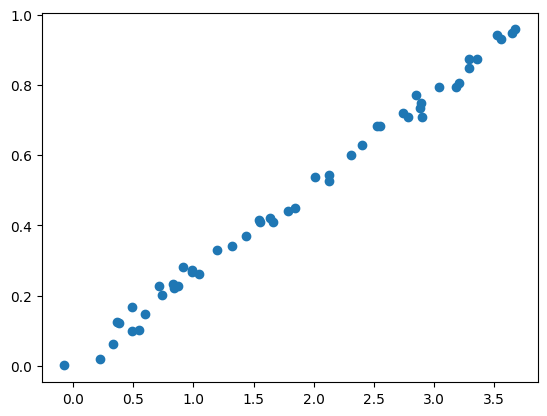

In [6]:
plt.scatter( mycebmf.L[:,0],u)

In [7]:
mycebmf.iter_once()
mycebmf._update_fitted_value()
import numpy as np
K=0
mycebmf.Y_fit 

tensor([[ 0.1119,  0.1069,  0.0388,  ...,  0.0013,  0.0632,  0.0817],
        [ 0.7496,  0.6967,  0.2225,  ...,  0.0124,  0.4137,  0.5187],
        [ 0.0934,  0.0906,  0.0349,  ..., -0.0368,  0.0456,  0.0611],
        ...,
        [ 0.6438,  0.5967,  0.2200,  ...,  0.0029,  0.3509,  0.4539],
        [ 0.3638,  0.3360,  0.1130,  ...,  0.0080,  0.1980,  0.2526],
        [ 0.0022,  0.0740,  0.0425,  ...,  0.0062,  0.0411,  0.0729]])

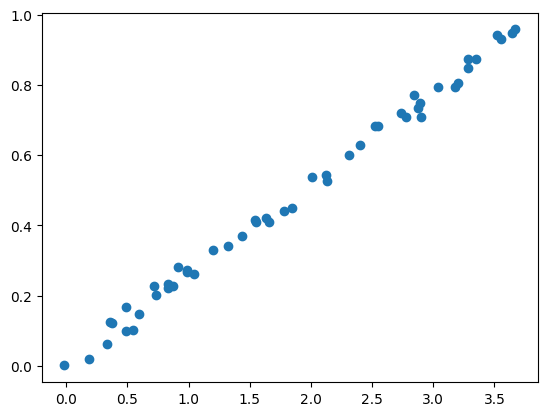

In [8]:
plt.scatter( mycebmf.L[:,0],u)

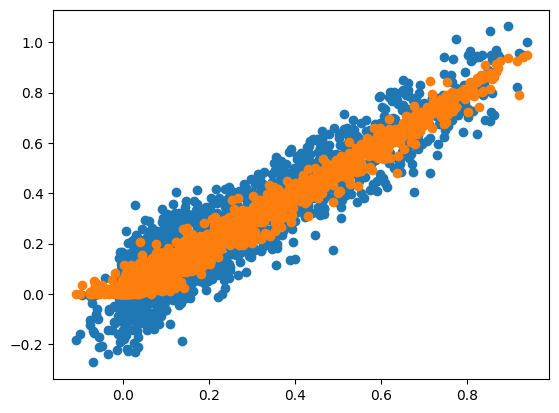

In [9]:
mycebmf.iter_once()  
plt.scatter(mycebmf.Y_fit, noisy_matrix)
 
plt.scatter(mycebmf.Y_fit, rank_1_matrix)

In [10]:
mycebmf=  cEBMF(data= noisy_matrix) 
mycebmf.initialise_factors()

In [11]:
mycebmf.fit()

CEBMFResult(L=tensor([[ 0.4853],
        [ 3.1639],
        [ 0.3720],
        [ 0.8605],
        [ 1.0344],
        [ 3.5090],
        [ 0.3184],
        [ 3.1400],
        [ 1.6105],
        [ 2.8645],
        [ 2.8433],
        [ 0.4814],
        [ 2.9991],
        [ 0.7254],
        [ 2.0967],
        [ 0.5369],
        [ 0.9718],
        [ 0.8231],
        [ 1.1792],
        [ 1.6372],
        [ 3.2416],
        [ 2.7410],
        [ 1.8219],
        [ 2.8078],
        [ 0.9027],
        [ 2.8511],
        [ 3.2404],
        [ 3.6241],
        [ 3.5964],
        [ 1.5216],
        [ 3.4796],
        [ 1.3030],
        [ 2.1011],
        [ 0.8166],
        [ 0.9747],
        [ 2.4891],
        [ 2.2823],
        [ 1.4140],
        [ 3.3100],
        [ 1.9807],
        [ 2.3687],
        [ 2.5189],
        [-0.0170],
        [ 0.5850],
        [ 0.1498],
        [ 1.7582],
        [ 0.7039],
        [ 2.7010],
        [ 1.5300],
        [ 0.3515]]), F=tensor([[0.2389],
        [0.219

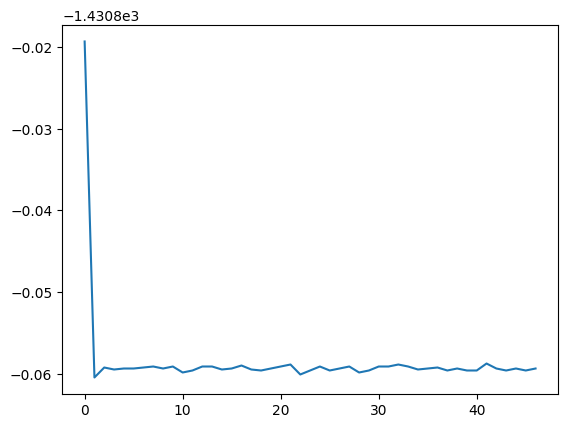

In [12]:
plt.plot(mycebmf.obj)

tensor(0.0012, dtype=torch.float64)

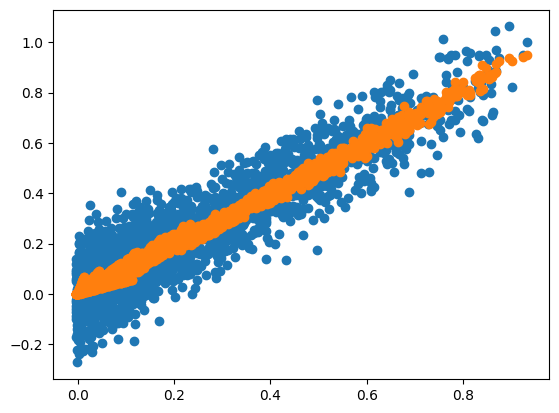

In [13]:
mycebmf._update_fitted_value()
plt.scatter(mycebmf.Y_fit, noisy_matrix)
 
plt.scatter(mycebmf.Y_fit, rank_1_matrix)
torch.sqrt(torch.mean(mycebmf.Y_fit- rank_1_matrix)**2)

In [14]:
results =[]
tau_est =[] 
    # Parameters
n, p = 50, 40
noise_std = 0.1

for i in range(100):
    torch.manual_seed(i)              # so you can match flashier seeds 1..100

    u = torch.rand(n, dtype=torch.float64, device=device)
    v = torch.rand(p, dtype=torch.float64, device=device)
    rank_1 = torch.outer(u, v)
    Y      = rank_1 + noise_std * torch.randn(n, p, dtype=torch.float64, device=device)

    m = cEBMF(data=Y, K=1)             # prior_L = prior_F = "norm" by default
    m.initialise_factors()              # SVD init
    m.fit(50)
    m._update_fitted_value()

    rmse = torch.sqrt(torch.mean((m.Y_fit - rank_1) ** 2)).item()
    var_hat = (1.0 / m.tau).item()
    results.append(rmse)
    tau_est.append(var_hat)

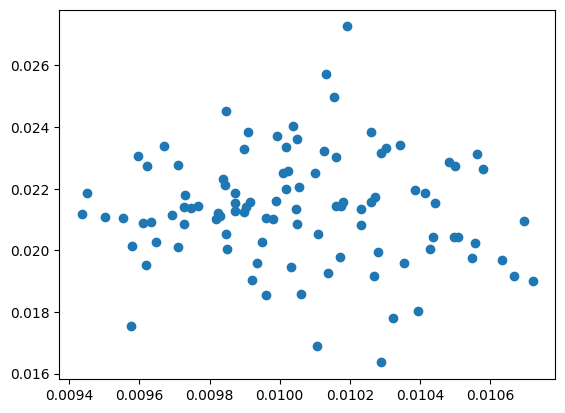

In [15]:
plt.scatter( tau_est, results)

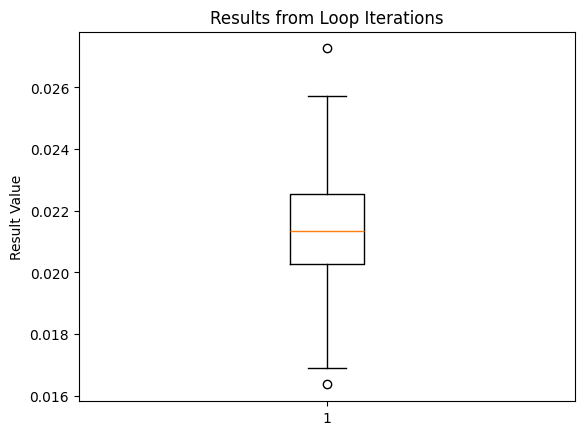

In [16]:
plt.boxplot(results)
plt.title("Results from Loop Iterations")
plt.ylabel("Result Value")
plt.show()

In [17]:
np.quantile(results,q=0.5)

np.float64(0.021336783145445355)

In [18]:
res= np.asarray(results)
np.mean(res )

np.float64(0.0213351462704815)

In [19]:
np.sqrt(np.var(res ))

np.float64(0.0018000071458258715)

In [20]:
# 0.002615278465597284